In [2]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob
import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *
from alvra_tools.alvra_widgets import Rebin_widget
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [4]:
pgroup = 'p22588'
runlist = [117]

data, meta = merge_multiple_runs(pgroup, runlist)

Processing run 117


100%|██████████| 35/35 [01:49<00:00,  3.14s/it]


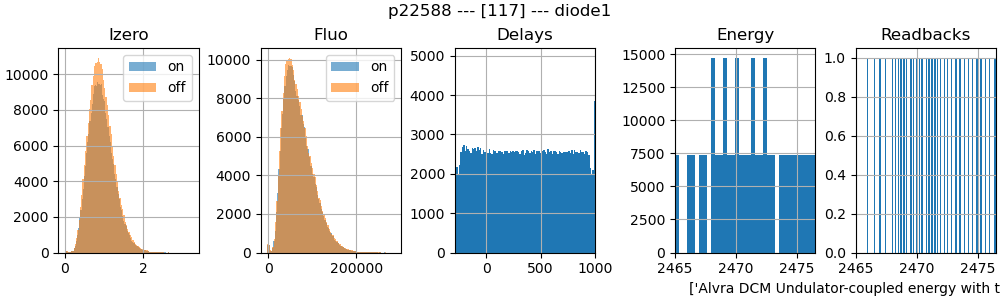

In [5]:
plot_merged_data(data, meta, Signal='diode1', Izero='Izero110', TT='126', withTT=True, bins=100, figsize=(10, 3))

In [6]:
ui, out  = Rebin_widget(data=data)
ui

In [23]:
data_plot1 = {"results": out['results1'], "params": out['params'], "which": "signal1"}
data_plot2 = {"results": out['results2'], "params": out['params'], "which": "signal2"}

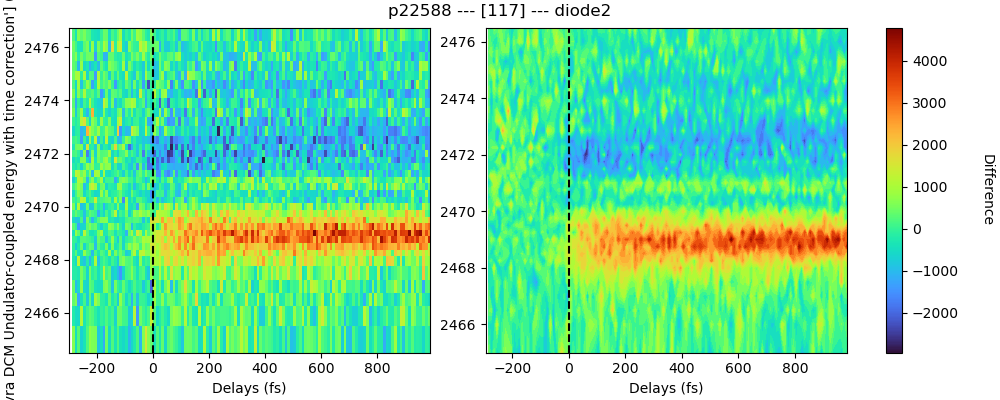

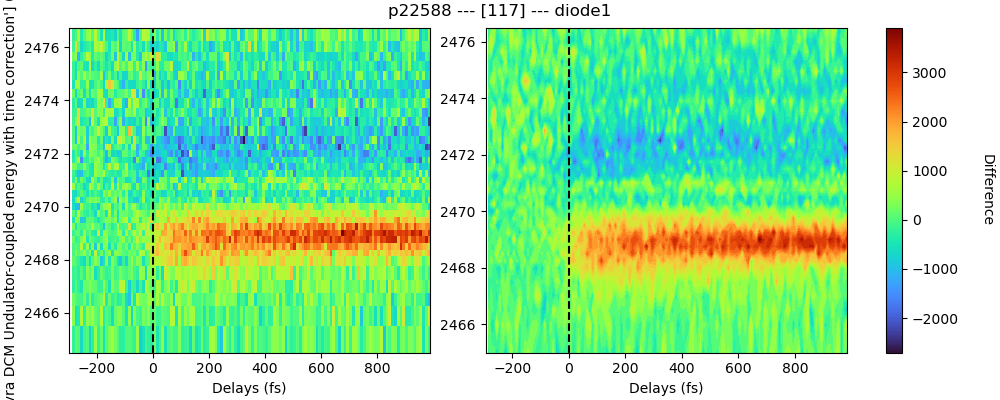

In [24]:
fig, axes = plotter.TwoD_scans(data_plot1, meta) #, vmin=-0.02, vmax=0.02)
fig, axes = plotter.TwoD_scans(data_plot2, meta) #, vmin=-0.02, vmax=0.02)

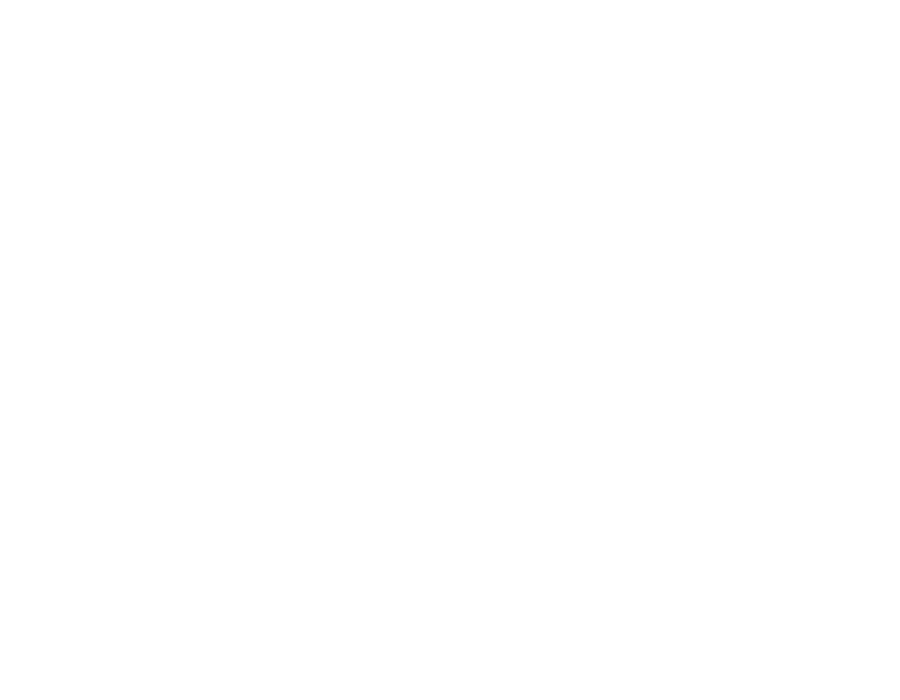

In [21]:
energylist = [2470.0, 2471.7, 2472.5,  2475.5]
delayslist = [0, 25, 50, 100, 200, 500, 800]

fig, axes = plotter.TwoD_scans_lineouts(data_plot1, meta, energylist, delayslist, 50, 0.5)#, vmin=-0.02, vmax=0.02)

In [25]:
SaveDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2, plot_both=None)

Data saved in /sf/alvra/data/p22588/work/Reduced_data/_singlerun/run0117/


In [28]:
pgroup = 'p22588'
runlist = [117]
which_folder = '_singlerun'
which_plot = 'plot2'

LoadDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
dataLoaded, runnames, whichdiode = LoadDataFlexible(SaveDir, runlist, which_folder=which_folder, which_plot=which_plot)

Loaded __diode1__ from: /sf/alvra/data/p22588/work/Reduced_data/_singlerun/run0117/data.npz


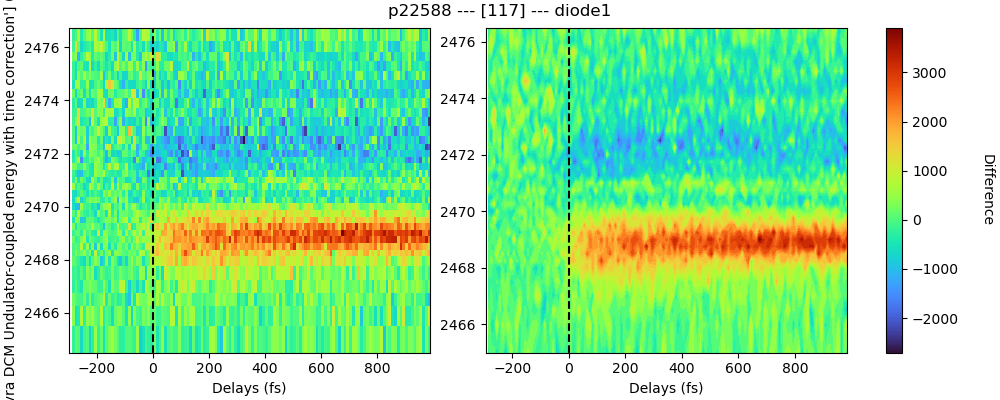

In [29]:
fig, axes = plotter.TwoD_scans(dataLoaded[0], meta) #, vmin=-0.02, vmax=0.02)